1. Day 1

Description of some terminology:

Datasets: A collection of data used for training or testing a model. It’s like the raw material for machine learning. Example: A CSV file containing information about houses (price, size, location, etc.).

Features (input variables or independent variables): These are the columns/attributes that describe the data. They are what the model uses to make predictions. Example: In house price prediction, features could be: Size (sq ft), Number of bedrooms, Location.

Label (target variable or dependent variable): This is what you are trying to predict. Example: In house price prediction, the Label is the Price.

DataFrame: A tabular data structure (like an Excel sheet in code). Most commonly used in pandas library in Python. It has rows (samples) and columns (features + label).

JSON: Stands for JavaScript Object Notation. A very popular lightweight format to store and exchange data. It likes a dictionary in Python.


Importing dataset.csv from kaggle.

In [1]:
import pandas as pd
from pathlib import Path
# Load dataset
BASE_DIR = Path().resolve().parent  # from notebooks → ml-project
df = pd.read_csv(BASE_DIR / "data" / "iris_dataset.csv")
# Preview
print(df.head())

   # data types & null values

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


Dataset Understanding

In [2]:
print("\nShape:", df.shape)
print("\nColumns:", df.columns)
print("\nInfo:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())


Shape: (150, 6)

Columns: Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='str')

Info:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB
None

Statistical Summary:
               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min      1.0000

Validate Extraction

In [3]:
# Features and target
X = df.drop("Species", axis=1)
y = df["Species"]

print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())


Features:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0   1            5.1           3.5            1.4           0.2
1   2            4.9           3.0            1.4           0.2
2   3            4.7           3.2            1.3           0.2
3   4            4.6           3.1            1.5           0.2
4   5            5.0           3.6            1.4           0.2

Target:
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: str


Generate Dataset Summary JSON

In [4]:
import json

summary = {
    "num_rows": df.shape[0],
    "num_columns": df.shape[1],
    "columns": list(df.columns),
    "missing_values": df.isnull().sum().to_dict(),
    "data_types": df.dtypes.astype(str).to_dict(),
    "target_distribution": df["Species"].value_counts().to_dict()
}

# Save JSON
output_path="../outputs/saadman_week1day1_data.json"
with open(output_path, "w") as f:
    json.dump(summary, f, indent=4)

print("\nDay 1 Summary JSON saved!")
print("Saved at:", output_path)


Day 1 Summary JSON saved!
Saved at: ../outputs/saadman_week1day1_data.json


Day 2


    Task:
    Step 1: Perform EDA (Exploratory Data Analysis) 
    Step 2: Generate Mean , Std , Distribution , Correlation 
    Step 3: Generate Histogram, Boxplots, correlation heatmap and store them appropriately 
    Step 4: Finding class imbalance
    Step 5: Convert findings into structured JSON, follow similar naming conventions 

In [5]:
stats = df.describe()

print('Description of Dataset\n',stats)

Description of Dataset
                Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min      1.000000       4.300000      2.000000       1.000000      0.100000
25%     38.250000       5.100000      2.800000       1.600000      0.300000
50%     75.500000       5.800000      3.000000       4.350000      1.300000
75%    112.750000       6.400000      3.300000       5.100000      1.800000
max    150.000000       7.900000      4.400000       6.900000      2.500000


In [6]:
# Mean & Std separately
df_withoutid=df.drop('Id',axis=1)
mean_values = df_withoutid.mean(numeric_only=True)
std_values = df_withoutid.std(numeric_only=True)

# Correlation
correlation = df_withoutid.corr(numeric_only=True)

# Class distribution
class_dist = df["Species"].value_counts()

print("Mean:\n",mean_values)
print("Standard Deviation:\n",std_values)
print("Correlation:\n",correlation)
print("Class Distribution:\n",class_dist)
print("We can see here no class imbalance presences.")

Mean:
 SepalLengthCm    5.843333
SepalWidthCm     3.054000
PetalLengthCm    3.758667
PetalWidthCm     1.198667
dtype: float64
Standard Deviation:
 SepalLengthCm    0.828066
SepalWidthCm     0.433594
PetalLengthCm    1.764420
PetalWidthCm     0.763161
dtype: float64
Correlation:
                SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
SepalLengthCm       1.000000     -0.109369       0.871754      0.817954
SepalWidthCm       -0.109369      1.000000      -0.420516     -0.356544
PetalLengthCm       0.871754     -0.420516       1.000000      0.962757
PetalWidthCm        0.817954     -0.356544       0.962757      1.000000
Class Distribution:
 Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64
We can see here no class imbalance presences.


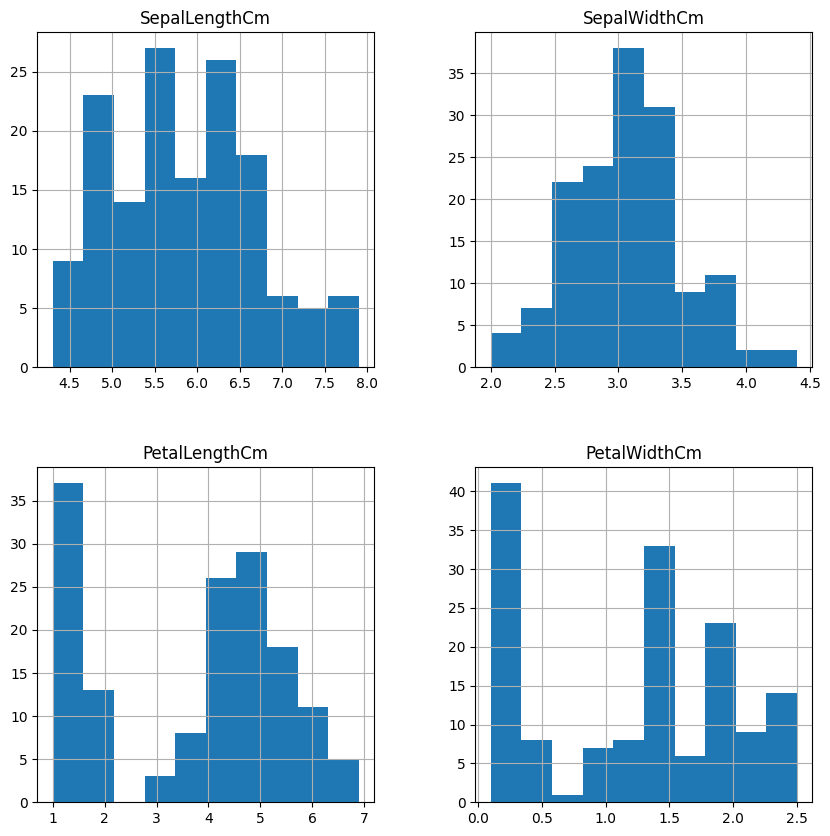

In [7]:
import matplotlib.pyplot as plt


df_withoutid.hist(figsize=(10,10))
plt.savefig(BASE_DIR / "outputs" / "histogram.png")
plt.show()

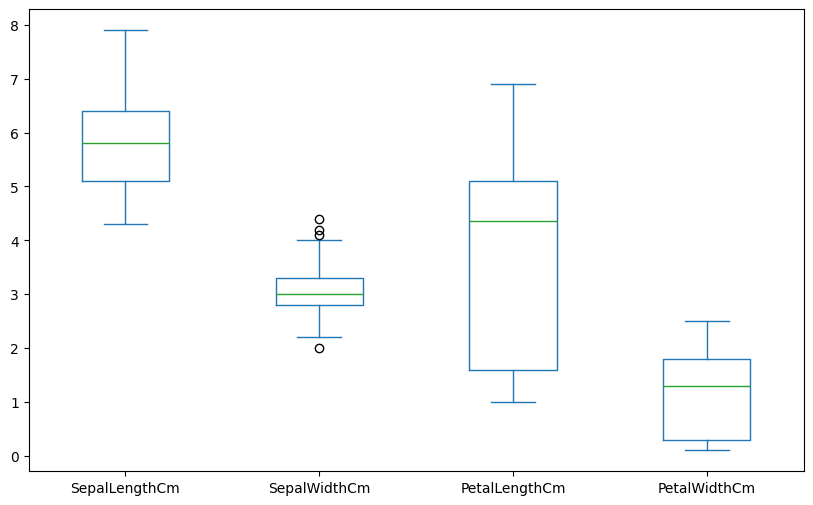

In [8]:
df_withoutid=df.drop('Id',axis=1)
df_withoutid.plot(kind='box', figsize=(10,6))
plt.savefig(BASE_DIR / "outputs" / "boxplot.png")
plt.show()

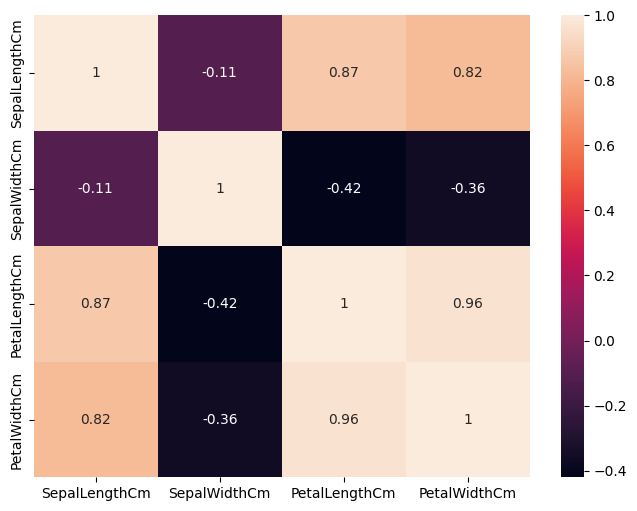

In [9]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True)
plt.savefig(BASE_DIR / "outputs" / "correlation_heatmap.png")
plt.show()

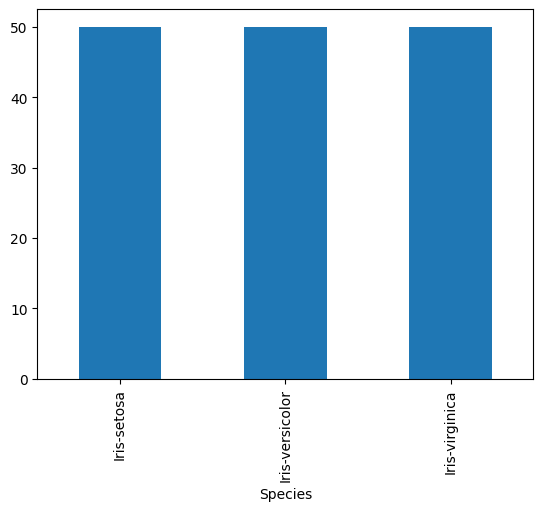

In [10]:
df["Species"].value_counts().plot(kind="bar")
plt.savefig(BASE_DIR / "outputs" / "check_any_class_imbalance.png")

In [11]:
import json

output_path = BASE_DIR / "outputs" / "saadman_week1day2_eda.json"
output_path.parent.mkdir(parents=True, exist_ok=True)

eda_summary = {
    "mean": mean_values.to_dict(),
    "std": std_values.to_dict(),
    "correlation": correlation.to_dict(),
    "class_distribution": class_dist.to_dict(),
    "observations": [
        "Dataset is balanced",
        "Petal features are strongly correlated as petal_length vs petal_width ≈ 0.96(correlation), Strong positive correlation",
        "Sepal features are weakly correlated, sepal_length vs sepal_width ≈ -0.11, Weak correlation",
        "No missing values",
        "Data distribution is approximately normal"
    ]
}

with open(output_path, "w") as f:
    json.dump(eda_summary, f, indent=4)

print("Day 2 JSON saved!")

Day 2 JSON saved!


DAY 3

Normalization:
Rescales features to a fixed range (usually 0–1).
Example:
x′=x-xmin\xmax−xmin
Used when: Neural networks, Distance-based models
Encoding:
Convert categorical data into numeric form.


In [ ]:

print(df.isnull().sum())

df = df.dropna()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [17]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["species_encoded"] = encoder.fit_transform(df["Species"])

print(df.head(100))

     Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
0     1            5.1           3.5            1.4           0.2   
1     2            4.9           3.0            1.4           0.2   
2     3            4.7           3.2            1.3           0.2   
3     4            4.6           3.1            1.5           0.2   
4     5            5.0           3.6            1.4           0.2   
..  ...            ...           ...            ...           ...   
95   96            5.7           3.0            4.2           1.2   
96   97            5.7           2.9            4.2           1.3   
97   98            6.2           2.9            4.3           1.3   
98   99            5.1           2.5            3.0           1.1   
99  100            5.7           2.8            4.1           1.3   

            Species  species_encoded  
0       Iris-setosa                0  
1       Iris-setosa                0  
2       Iris-setosa                0  
3       Iris-se

In [21]:
from sklearn.preprocessing import StandardScaler

features = df.drop(["Species", "species_encoded"], axis=1)

scaler = StandardScaler()

scaled_data = scaler.fit_transform(features)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=features.columns
)

scaled_df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,-1.720542,-0.900681,1.032057,-1.341272,-1.312977
1,-1.697448,-1.143017,-0.124958,-1.341272,-1.312977
2,-1.674353,-1.385353,0.337848,-1.398138,-1.312977
3,-1.651258,-1.506521,0.106445,-1.284407,-1.312977
4,-1.628164,-1.021849,1.263460,-1.341272,-1.312977


In [23]:
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()

normalized = minmax.fit_transform(features)

normalized_df = pd.DataFrame(
    normalized,
    columns=features.columns
)

normalized_df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,0.000000,0.222222,0.625000,0.067797,0.041667
1,0.006711,0.166667,0.416667,0.067797,0.041667
2,0.013423,0.111111,0.500000,0.050847,0.041667
3,0.020134,0.083333,0.458333,0.084746,0.041667
4,0.026846,0.194444,0.666667,0.067797,0.041667


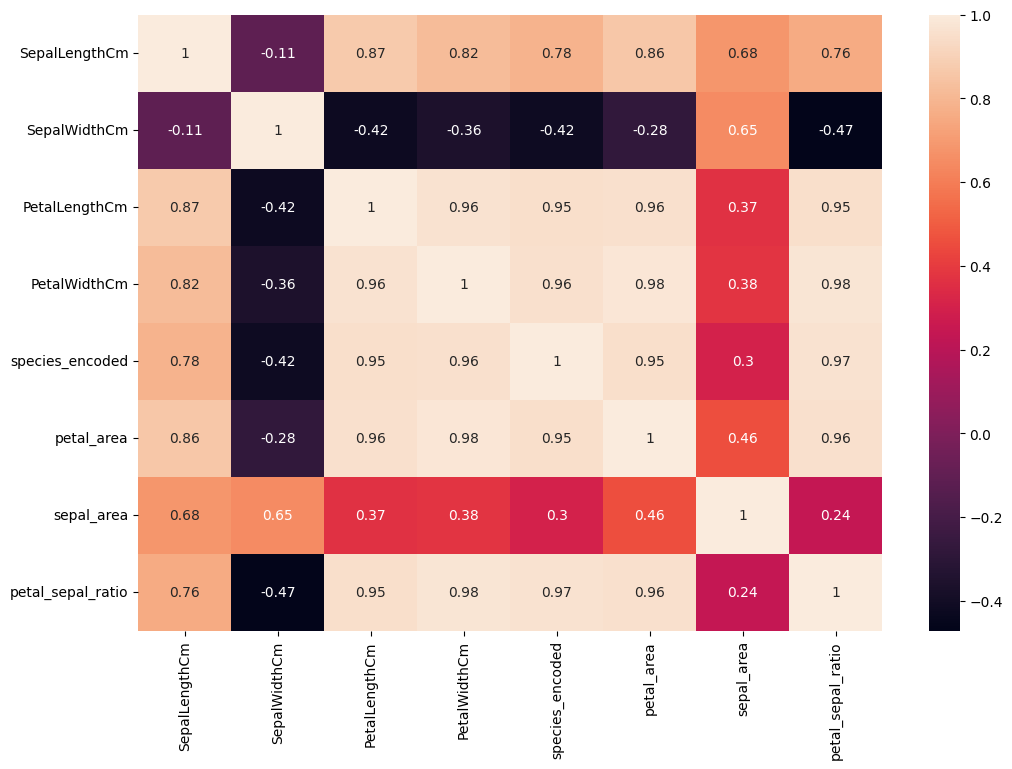

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,species_encoded,petal_area,sepal_area,petal_sepal_ratio
0,5.1,3.5,1.4,0.2,Iris-setosa,0,0.28,17.85,0.015686
1,4.9,3.0,1.4,0.2,Iris-setosa,0,0.28,14.70,0.019048
2,4.7,3.2,1.3,0.2,Iris-setosa,0,0.26,15.04,0.017287
3,4.6,3.1,1.5,0.2,Iris-setosa,0,0.30,14.26,0.021038
4,5.0,3.6,1.4,0.2,Iris-setosa,0,0.28,18.00,0.015556


In [26]:
df["petal_area"] = (
    df["PetalLengthCm"] *
    df["PetalWidthCm"]
)
df["sepal_area"] = (
    df["SepalLengthCm"] *
    df["SepalWidthCm"]
)
df["petal_sepal_ratio"] = (
    df["petal_area"] /
    df["sepal_area"]
)
df1=df.drop('Id',axis=1)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    df1.corr(numeric_only=True),
    annot=True
)

plt.savefig(
    BASE_DIR / "outputs/day3_correlation.png"
)

plt.show()
df1.head()

In [ ]:
#Saved engineered datasets
df.to_csv(
    BASE_DIR / "outputs/iris_dataset_engineered.csv",
    index=False
)

In [29]:
import json

summary = {
    "encoding": {
        "setosa": 0,
        "versicolor": 1,
        "virginica": 2
    },

    "scaling_applied": [
        "StandardScaler",
        "MinMaxScaler"
    ],

    "new_features": [
        "petal_area",
        "sepal_area",
        "petal_sepal_ratio"
    ],

    "observations": [
        "No missing data",
        "Labels successfully encoded",
        "Features standardized",
        "Normalization successful",
        "Engineered features improved correlation patterns"
    ]
}

with open(
    BASE_DIR / "outputs/saadman_week1day3_features.json",
    "w"
) as f:
    json.dump(summary, f, indent=4)

print("Day 3 complete")

Day 3 complete


Day 4

Machine Learning Model:
A mathematical system that learns patterns from data. Example:
Logistic Regression
SVM
Random Forest

Training:
The process of learning from data.

In [33]:
X = df.drop(["Species", "species_encoded"],axis=1)

y = df["species_encoded"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [47]:
# used LogisticRegression, DecisionTreeClassifier, RandomForestClassifier, SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=200),

    "Decision Tree":
        DecisionTreeClassifier(max_depth=3),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),

    "SVM":
        SVC(kernel='linear')
}

In [48]:
results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        preds
    )

    results[name] = accuracy

    print(f"{name}: {accuracy:.4f}")

Logistic Regression: 1.0000
Decision Tree: 1.0000
Random Forest: 1.0000
SVM: 1.0000


c:\Users\revon\Desktop\ml-ramo-up-week1-saadman\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [51]:
best_model_name = max(
    results,
    key=results.get
)

print("Best Model:", best_model_name)

best_model = models[best_model_name]

Best Model: Logistic Regression


In [52]:
predictions = best_model.predict(X_test)

prediction_df = X_test.copy()

prediction_df["actual"] = y_test.values
prediction_df["predicted"] = predictions

prediction_df.to_csv(
    BASE_DIR / "outputs/day4_predictions.csv",
    index=False
)

In [53]:
import joblib

joblib.dump(
    best_model,
    BASE_DIR / "outputs/best_model.joblib"
)

['C:\\Users\\revon\\Desktop\\ml-ramo-up-week1-saadman\\outputs\\best_model.joblib']

In [54]:
import json

summary = {

    "model_results": results,

    "best_model": best_model_name,

    "observations": [

        "SVM and Random Forest performed very well",

        "Decision Tree showed slightly lower accuracy",

        "Iris dataset is simple and highly separable",

        "Multiple models achieved near-perfect accuracy"
    ]
}

with open(
    BASE_DIR / "outputs/saadman_week1day4_model_comparison.json",
    "w"
) as f:
    json.dump(summary, f, indent=4)

Day 5

In [55]:
import pandas as pd
from pathlib import Path
import joblib

BASE_DIR = Path().resolve().parent

df = pd.read_csv(
    BASE_DIR / "outputs" / "iris_dataset_engineered.csv"
)

model = joblib.load(
    BASE_DIR / "outputs" / "best_model.joblib"
)

In [59]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(
    y_test,
    predictions
)

precision = precision_score(
    y_test,
    predictions,
    average="weighted"
)

recall = recall_score(
    y_test,
    predictions,
    average="weighted"
)

f1 = f1_score(
    y_test,
    predictions,
    average="weighted"
)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


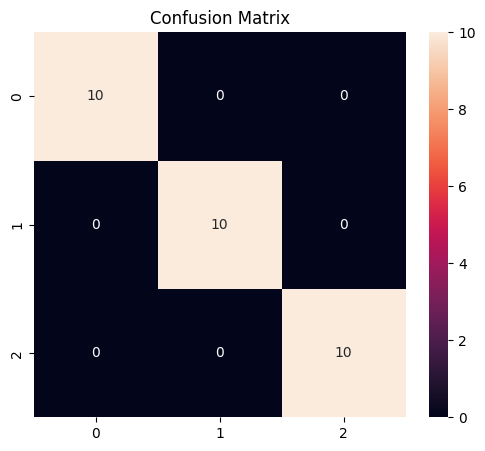

In [56]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.savefig(
    BASE_DIR / "outputs/day5_confusion_matrix.png"
)

plt.show()

In [60]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

cv_model = LogisticRegression(
    max_iter=200
)

cv_scores = cross_val_score(
    cv_model,
    X,
    y,
    cv=5
)

print("CV Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())

CV Scores: [0.8 1.  1.  1.  0.8]
Average CV Score: 0.9199999999999999


c:\Users\revon\Desktop\ml-ramo-up-week1-saadman\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\revon\Desktop\ml-ramo-up-week1-saadman\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-le

In [61]:
import json

summary = {

    "metrics": {
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1_score": float(f1)
    },

    "cross_validation": {
        "scores": cv_scores.tolist(),
        "mean_score": float(cv_scores.mean())
    },

    "observations": [
        "Model performance is very high",
        "Cross-validation indicates stable generalization",
        "No severe overfitting observed",
        "Dataset balance improved metric consistency"
    ]
}

with open(
    BASE_DIR / "outputs/saadman_week1day5_metrics.json",
    "w"
) as f:
    json.dump(summary, f, indent=4)

print("Day 5 completed")

Day 5 completed


Day 6

In [63]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

models = {

    "LogisticRegression":
    Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=200))
    ]),

    "DecisionTree":
    Pipeline([
        ("scaler", StandardScaler()),
        ("model", DecisionTreeClassifier(max_depth=3))
    ]),

    "RandomForest":
    Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]),

    "SVM":
    Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="linear"))
    ])
}

In [64]:
results = {}
errors = []

for name, pipeline in models.items():

    try:

        pipeline.fit(X_train, y_train)

        predictions = pipeline.predict(X_test)

        accuracy = accuracy_score(
            y_test,
            predictions
        )

        precision = precision_score(
            y_test,
            predictions,
            average="weighted"
        )

        recall = recall_score(
            y_test,
            predictions,
            average="weighted"
        )

        f1 = f1_score(
            y_test,
            predictions,
            average="weighted"
        )

        cv_scores = cross_val_score(
            pipeline,
            X,
            y,
            cv=5
        )

        results[name] = {

            "accuracy": float(accuracy),

            "precision": float(precision),

            "recall": float(recall),

            "f1_score": float(f1),

            "cv_mean": float(cv_scores.mean())
        }

        print(f"{name} completed")

    except Exception as e:

        errors.append({
            "model": name,
            "error": str(e)
        })

        print(f"{name} failed")

LogisticRegression completed
DecisionTree completed
RandomForest completed
SVM completed


In [65]:
best_model_name = max(
    results,
    key=lambda x: results[x]["accuracy"]
)

best_model = models[best_model_name]

print("Best Model:", best_model_name)

Best Model: LogisticRegression


In [66]:
model_dir = BASE_DIR / "outputs" / "saved_models"

model_dir.mkdir(
    parents=True,
    exist_ok=True
)

for name, pipeline in models.items():

    joblib.dump(
        pipeline,
        model_dir / f"{name}.joblib"
    )

In [67]:
summary = {

    "results": results,

    "best_model": best_model_name,

    "observations": [

        "SVM and RandomForest performed strongly",

        "DecisionTree showed slightly lower stability",

        "Cross-validation scores remained consistent",

        "Pipeline prevented preprocessing leakage"
    ]
}

with open(
    BASE_DIR /
    "outputs" /
    "saadman_week1day6_pipeline.json",
    "w"
) as f:

    json.dump(summary, f, indent=4)

In [69]:
error_log = {

    "errors": errors,

    "missing_outputs": []
}
for model_name, metrics in results.items():

    for metric_name, value in metrics.items():

        if value is None:

            error_log["missing_outputs"].append({

                "model": model_name,

                "metric": metric_name
            })

with open(
    BASE_DIR /
    "outputs" /
    "saadman_week1day6_errors.json",
    "w"
) as f:

    json.dump(error_log, f, indent=4)

In [70]:
loaded_model = joblib.load(
    BASE_DIR /
    "outputs" /
    "saved_models" /
    "SVM.joblib"
)

sample_prediction = loaded_model.predict(
    X_test.iloc[:5]
)

print(sample_prediction)

[0 2 1 1 0]
